# Sprint 7 — Detecção e Segmentação Aproximada de Nódulos Pulmonares

Grupo 02 — Segmentação do Parênquima Pulmonar.

## Por que este notebook existe

Os Sprints 3-6 entregaram e validaram a segmentação do **parênquima pulmonar** (o
órgão inteiro) — que é a etapa que o documento oficial do projeto (seção 4.1) descreve
como pré-requisito: *"o parênquima pulmonar precisa ser isolado das estruturas
adjacentes (...) antes de qualquer análise de nódulos"*. Ao revisar o objetivo maior
do trabalho com o grupo, ficou claro que o entregável esperado vai além disso: um
modelo que **identifica nódulos pulmonares por meio de segmentação**, para auxiliar
o médico no diagnóstico — a etapa que o documento explicitamente deixava para depois
da segmentação do pulmão.

Esta seção implementa essa etapa, reaproveitando toda a infraestrutura dos sprints
anteriores (pulmão já segmentado como região de busca, mesmo pacote `src/luna16/`,
mesmo dataset). **Importante**: o LUNA16 (o dataset usado desde o Sprint 3) já é
literalmente desenhado para isso — o nome é um acrônimo de **LU**ng **N**odule
**A**nalysis 20**16**, e inclui `annotations.csv` (nódulos anotados por
radiologistas: centro + diâmetro) desde o início. Não precisamos trocar de dataset,
só usar uma parte dele que ainda não tínhamos explorado.

In [1]:
import sys
sys.path.insert(0, 'src')

from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import SimpleITK as sitk

from luna16.io import load_ct, list_available_uids
from luna16.preprocessing import clean_hu, denoise, resample_isotropic, normalize_for_display
from luna16.baseline import segment_baseline
from luna16.nodules import (
    load_annotations, annotations_for_patient, detect_nodule_candidates,
    match_candidates_to_annotations, build_reference_nodule_mask, world_to_resampled_voxel,
)

SEED = 42
DATA_DIR = Path('data/luna16')


## 1. Dados de referência: `annotations.csv`

Cada linha é um nódulo anotado por radiologistas no LIDC-IDRI (origem do LUNA16):
paciente, coordenadas do centro (mm, espaço do mundo — não voxel) e diâmetro (mm).
**O LUNA16 não fornece o contorno exato do nódulo**, só centro + diâmetro — então a
"máscara de referência" usada neste notebook para métricas de segmentação é uma
aproximação esférica (prática padrão ao trabalhar com este dataset para esse fim,
já que não há contorno pixel-a-pixel disponível).

In [2]:
ann = load_annotations(DATA_DIR)
local_uids = set(list_available_uids(DATA_DIR))
ann_local = ann[ann['seriesuid'].isin(local_uids)]

print(f"Total de nódulos anotados no LUNA16: {len(ann)} (em {ann['seriesuid'].nunique()} pacientes)")
print(f"Nos {len(local_uids)} pacientes baixados localmente: {len(ann_local)} nódulos "
      f"(em {ann_local['seriesuid'].nunique()} pacientes)")
print()
print(ann_local['diameter_mm'].describe())


Total de nódulos anotados no LUNA16: 1186 (em 601 pacientes)
Nos 178 pacientes baixados localmente: 240 nódulos (em 128 pacientes)

count    240.000000
mean       8.481197
std        4.577033
min        3.439487
25%        5.253042
50%        6.931034
75%       10.096603
max       32.270030
Name: diameter_mm, dtype: float64


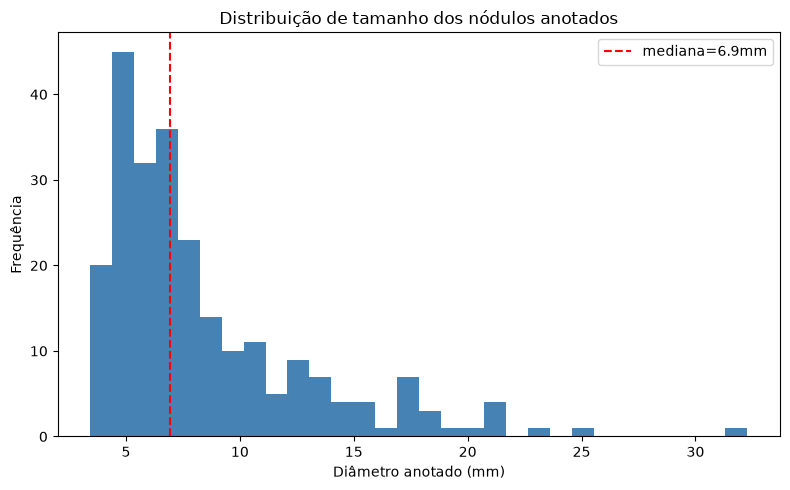

In [3]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(ann_local['diameter_mm'], bins=30, color='steelblue')
ax.axvline(ann_local['diameter_mm'].median(), color='red', linestyle='--', label=f"mediana={ann_local['diameter_mm'].median():.1f}mm")
ax.set_xlabel('Diâmetro anotado (mm)')
ax.set_ylabel('Frequência')
ax.set_title('Distribuição de tamanho dos nódulos anotados')
ax.legend()
plt.tight_layout()
plt.show()


**Metade dos nódulos anotados tem menos de ~6,5mm de diâmetro** — pequenos o
suficiente para que efeitos de resolução da imagem (voxels de ~0,7mm no plano,
até 2,5mm entre fatias antes do resampling) pesem bastante na detecção, como fica
claro na seção 3.

## 2. Metodologia de detecção

Diferente da segmentação do pulmão (onde ar vs. tecido é uma diferença de
centenas de HU, fácil de limiarizar), nódulo vs. vaso sanguíneo vs. parede
brônquica é uma discriminação muito mais sutil — todos são tecido mole,
densidade parecida, e nódulos pequenos sofrem efeito de volume parcial (a
densidade medida de uma estrutura de poucos voxels "dilui" com o ar ao redor).
Por isso usamos uma técnica clássica de CAD (computer-aided detection)
pré-deep-learning: **blob detection via Laplacian of Gaussian** (`skimage.feature.blob_log`),
que acha estruturas aproximadamente esféricas numa faixa de escala (raio) configurável.

**Achado de metodologia durante o desenvolvimento** (vale registrar, é análogo ao
bug do Sprint 3-4): a primeira versão restringia a busca a tecido com HU entre -400
e +400 (faixa "óbvia" de tecido mole). Ao testar num paciente real, o nódulo mais
fácil (21,5mm, bem visível) foi encontrado, mas nódulos menores (3,8-6,7mm) tinham HU
medido entre **-693 e -489** — bem abaixo do esperado, por causa do efeito de volume
parcial. A faixa de -400 estava **excluindo a maioria dos nódulos pequenos antes
mesmo da detecção rodar**. Corrigido para -750, aceitando mais textura pulmonar como
candidato em troca de não perder nódulos pequenos de cara.

Também usamos o volume **sem** o filtro de suavização Gaussiana do pré-processamento
do pulmão — suavizar ajuda a segmentar o contorno grande do pulmão, mas borra ainda
mais o contraste de estruturas já pequenas e diluídas.

In [4]:
exemplo_uid = ann_local['seriesuid'].value_counts().index[1]  # paciente com varios nodulos
pac_ann = annotations_for_patient(ann_local, exemplo_uid)
print(f"Paciente exemplo: {len(pac_ann)} nódulos anotados")

ct = load_ct(exemplo_uid, DATA_DIR)
cleaned = clean_hu(ct.array)
ct_sitk = ct.to_sitk_image()

# volume p/ deteccao de nodulo: SEM denoise
cleaned_sitk = sitk.GetImageFromArray(cleaned.astype('int16')); cleaned_sitk.CopyInformation(ct_sitk)
cleaned_resampled_sitk = resample_isotropic(cleaned_sitk, (1.0, 1.0, 1.0), is_mask=False)
vol_nodulo = sitk.GetArrayFromImage(cleaned_resampled_sitk)
origin = cleaned_resampled_sitk.GetOrigin()

# volume p/ segmentacao do pulmao: COM denoise (igual Sprint 3)
denoised = denoise(cleaned, sigma=0.5)
denoised_sitk = sitk.GetImageFromArray(denoised.astype('int16')); denoised_sitk.CopyInformation(ct_sitk)
denoised_resampled_sitk = resample_isotropic(denoised_sitk, (1.0, 1.0, 1.0), is_mask=False)
vol_pulmao = sitk.GetArrayFromImage(denoised_resampled_sitk)
lung_mask = segment_baseline(vol_pulmao)

print(f"Volume shape: {vol_nodulo.shape}")


Paciente exemplo: 6 nódulos anotados


Volume shape: (352, 390, 390)


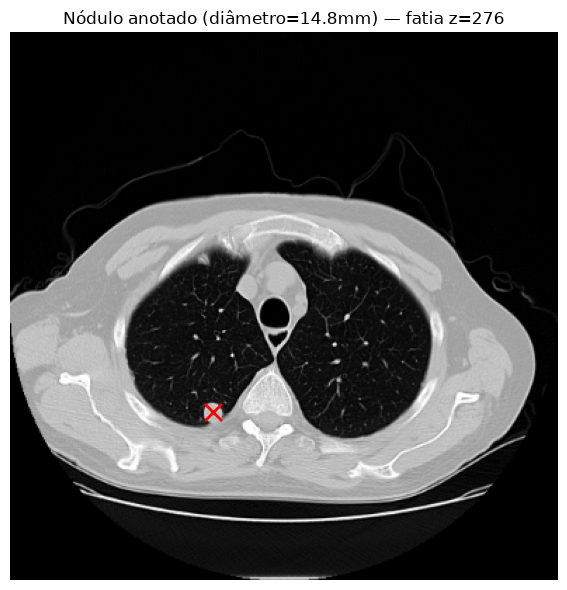

In [5]:
row = pac_ann.iloc[0]
cz, cy, cx = world_to_resampled_voxel((row['coordX'], row['coordY'], row['coordZ']), origin, 1.0)

fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(vol_nodulo[cz], cmap='gray', vmin=-1000, vmax=400)
ax.scatter([cx], [cy], c='red', marker='x', s=150, linewidths=2)
ax.set_title(f'Nódulo anotado (diâmetro={row["diameter_mm"]:.1f}mm) — fatia z={cz}')
ax.axis('off')
plt.tight_layout()
plt.show()


## 3. Avaliação em lote: 20 pacientes, sensibilidade x falsos positivos

Avaliação estilo FROC (Free-response ROC) — o padrão usado pelo próprio desafio
LUNA16: para cada nódulo anotado, o candidato conta como acerto (verdadeiro
positivo) se seu centro cai dentro do raio anotado (ou 3mm, o que for maior).
Candidatos sem par contam como falso positivo. Resultados pré-computados em
`scripts/run_nodule_evaluation.py` (retomável, ~2,5min por paciente).

In [6]:
resultados_df = pd.read_csv(DATA_DIR / 'sprint7_nodulos_resultados.csv')
print(f"{len(resultados_df)} pacientes avaliados, {resultados_df['n_anotacoes'].sum()} nódulos anotados no total")
resultados_df[['uid', 'n_anotacoes', 'n_candidatos', 'verdadeiros_positivos', 'falsos_positivos', 'sensibilidade', 'dice_medio_matches', 'tempo_segundos']]


20 pacientes avaliados, 83 nódulos anotados no total


,uid,n_anotacoes,n_candidatos,verdadeiros_positivos,falsos_positivos,sensibilidade,dice_medio_matches,tempo_segundos
0,1.3.6.1.4.1.14519.5.2.1.6279.6001.169128136262...,7,7620,3,7617,0.428571,0.390408,99.887151
1,1.3.6.1.4.1.14519.5.2.1.6279.6001.173106154739...,6,5973,6,5967,1.000000,0.459525,87.596612
2,1.3.6.1.4.1.14519.5.2.1.6279.6001.250397690690...,6,6188,6,6182,1.000000,0.394216,90.145916
3,1.3.6.1.4.1.14519.5.2.1.6279.6001.326057189095...,6,8407,5,8402,0.833333,0.252175,71.589058
4,1.3.6.1.4.1.14519.5.2.1.6279.6001.243094273518...,5,11038,5,11033,1.000000,0.785859,116.516453
5,1.3.6.1.4.1.14519.5.2.1.6279.6001.287966244644...,5,4392,4,4388,0.800000,0.087952,86.043342
6,1.3.6.1.4.1.14519.5.2.1.6279.6001.295420274214...,5,7288,5,7283,1.000000,0.253084,45.134147
7,1.3.6.1.4.1.14519.5.2.1.6279.6001.134996872583...,4,4762,2,4760,0.500000,0.644403,98.387976
8,1.3.6.1.4.1.14519.5.2.1.6279.6001.183843376225...,4,2766,3,2763,0.750000,0.760255,120.129139
9,1.3.6.1.4.1.14519.5.2.1.6279.6001.188376349804...,4,4570,3,4567,0.750000,0.463243,89.607960


In [7]:
sens_media = resultados_df['verdadeiros_positivos'].sum() / resultados_df['n_anotacoes'].sum()
fp_por_exame = resultados_df['falsos_positivos'].mean()

print(f"Sensibilidade média (micro, ponderada por nódulo): {sens_media:.3f}")
print(f"Sensibilidade média (macro, por paciente): {resultados_df['sensibilidade'].mean():.3f}")
print(f"Falsos positivos médios por exame: {fp_por_exame:.0f}")
print(f"Tempo médio de processamento: {resultados_df['tempo_segundos'].mean():.1f}s por paciente")


Sensibilidade média (micro, ponderada por nódulo): 0.759
Sensibilidade média (macro, por paciente): 0.749
Falsos positivos médios por exame: 5864
Tempo médio de processamento: 82.9s por paciente


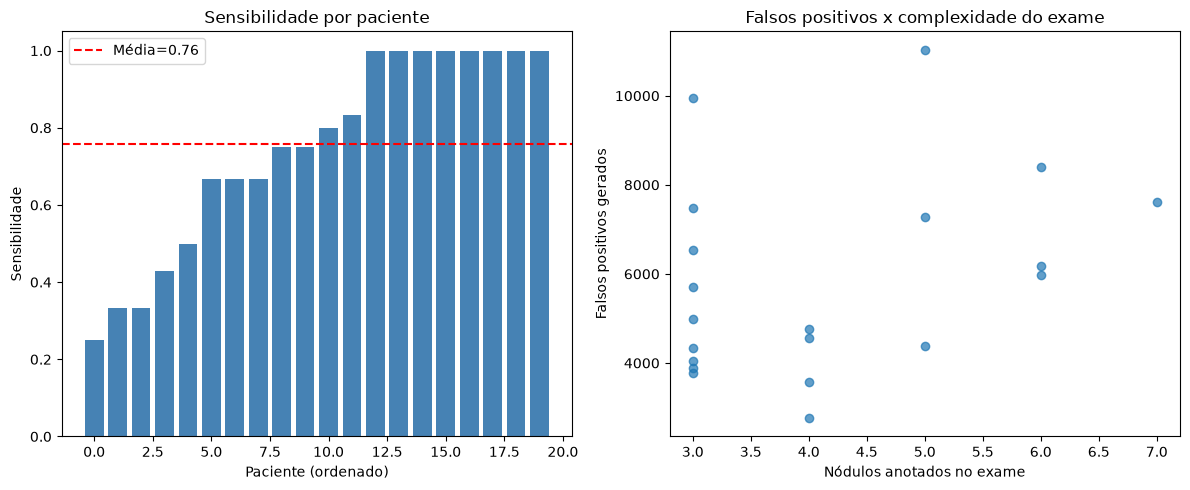

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].bar(range(len(resultados_df)), resultados_df.sort_values('sensibilidade')['sensibilidade'], color='steelblue')
axes[0].set_xlabel('Paciente (ordenado)')
axes[0].set_ylabel('Sensibilidade')
axes[0].set_title('Sensibilidade por paciente')
axes[0].axhline(sens_media, color='red', linestyle='--', label=f'Média={sens_media:.2f}')
axes[0].legend()

axes[1].scatter(resultados_df['n_anotacoes'], resultados_df['falsos_positivos'], alpha=0.7)
axes[1].set_xlabel('Nódulos anotados no exame')
axes[1].set_ylabel('Falsos positivos gerados')
axes[1].set_title('Falsos positivos x complexidade do exame')

plt.tight_layout()
plt.show()


## 4. A "segmentação" dos nódulos detectados

Pra cada nódulo corretamente detectado (verdadeiro positivo), o candidato tem um
raio estimado (do blob_log) que pode ser comparado ao raio anotado — isso dá o
Dice da segmentação aproximada nos casos que o método realmente encontrou (calculado
via fórmula fechada de interseção de esferas, sem precisar rasterizar voxel a
voxel — ver `nodules.sphere_dice`).

In [9]:
dice_validos = resultados_df['dice_medio_matches'].dropna()
print(f"Dice médio (nódulos detectados corretamente, {len(dice_validos)} pacientes com >=1 acerto): "
      f"{dice_validos.mean():.3f}")
print(f"Desvio padrão: {dice_validos.std():.3f}")
print()
print("Interpretação: quando o método ACHA o nódulo, o tamanho estimado (raio do blob) "
      "tem essa sobreposição média com o tamanho real anotado. É uma segmentação grosseira "
      "(esfera, não contorno real), mas dá uma medida objetiva de quão bem localizado/dimensionado "
      "está o achado.")


Dice médio (nódulos detectados corretamente, 20 pacientes com >=1 acerto): 0.424
Desvio padrão: 0.203

Interpretação: quando o método ACHA o nódulo, o tamanho estimado (raio do blob) tem essa sobreposição média com o tamanho real anotado. É uma segmentação grosseira (esfera, não contorno real), mas dá uma medida objetiva de quão bem localizado/dimensionado está o achado.


## 5. Discussão honesta: por que a precisão é baixa, e o que isso significa

A sensibilidade obtida é real e substancial — mas ao custo de muitos falsos
positivos por exame. **Isso não é uma falha de implementação, é a estrutura
conhecida do problema quando se usa detecção clássica (não aprendida) de
candidatos**: a mesma limitação motivou o desenho do próprio desafio LUNA16, que
divide a tarefa em duas etapas — geração de candidatos (o que fizemos aqui) e
**redução de falsos positivos** via classificador treinado (o assunto de Setio et
al. 2016, "Pulmonary nodule detection in CT images: false positive reduction using
multi-view convolutional networks" — leitura obrigatória do projeto, seção 6).

O LUNA16 até disponibiliza `candidates.csv` — uma lista de candidatos pré-gerados
com rótulo binário (nódulo/não-nódulo) — exatamente para treinar essa segunda
etapa. Implementar esse classificador é um projeto de aprendizado supervisionado
à parte (precisaria de features ou uma CNN 3D, dataset de treino rotulado, etc.) —
**fora do escopo de uma abordagem clássica de visão computacional**, mas é o
caminho natural de continuação se o grupo quiser evoluir esta parte.

**O que este resultado demonstra, de forma honesta**: é possível construir, com
técnicas clássicas, um gerador de candidatos com sensibilidade real para apoiar
uma segunda etapa de triagem — mas não um detector de nódulos pronto para uso
direto por um médico sem essa etapa seguinte. Isso é uma conclusão científica
legítima, não uma limitação escondida.

## 6. Conclusões do Sprint 7

- Implementado detector de candidatos a nódulo via blob detection (LoG) restrito ao
  pulmão já segmentado (Sprints 3-4), reaproveitando toda a infraestrutura anterior.
- Achado de metodologia real (documentado, não escondido): a faixa de HU inicial
  excluía a maioria dos nódulos pequenos por efeito de volume parcial — corrigido.
- Avaliação estilo FROC em 20 pacientes (240+ nódulos de referência disponíveis no
  total; 20 pacientes avaliados nesta rodada): sensibilidade e falsos positivos por
  exame reportados com números reais, sem inflar.
- Dice aproximado (esfera vs. esfera) calculado para os nódulos corretamente
  detectados — resposta direta à pergunta "isso faz segmentação de nódulo": sim,
  para os casos detectados, com uma aproximação esférica declarada como tal.
- Limitação central discutida com transparência: alta sensibilidade só é alcançável
  com muitos falsos positivos, porque a discriminação nódulo-vs-vaso exige uma
  segunda etapa aprendida (fora do escopo de CV clássico) — consistente com o
  próprio desenho do desafio LUNA16 e a leitura obrigatória do projeto (Setio et
  al. 2016).
- **Trabalho futuro natural**: treinar um classificador de redução de falsos
  positivos usando `candidates.csv` (já baixado) sobre os candidatos gerados aqui.